# Expérimentations & Améliorations — V2 (après Data Augmentation)
#### Waste Classification — MobileNetV2

Ce notebook reprend les **mêmes 3 expériences** que `experiments_improvements.ipynb`,
mais entraîné sur le **dataset enrichi** après augmentation offline de la classe `trash`.

| Expérience | Technique | Objectif |
|---|---|---|
| **Exp 1** | Class weights | Corriger le déséquilibre résiduel |
| **Exp 2** | Fine-tuning MobileNetV2 | Débloquer les 30 dernières couches |
| **Exp 3** | Class weights + Fine-tuning | Combiner les deux |

> **Contexte** : La classe `trash` a été enrichie via `data_augmentation_trash.ipynb`
> (3 variations par image originale → dataset équilibré).
> Les résultats sont sauvegardés sous des noms **`_v2`** pour ne pas écraser
> les résultats originaux de `experiments_improvements.ipynb`.

| Fichier | Version originale | Version V2 (ce notebook) |
|---|---|---|
| Modèles | `exp1_class_weights.keras` | `v2_exp1_class_weights.keras` |
| Modèles | `exp2_fine_tuned.keras` | `v2_exp2_fine_tuned.keras` |
| Modèles | `exp3_combined.keras` | `v2_exp3_combined.keras` |
| Graphiques | `experiments_comparison.png` | `v2_experiments_comparison.png` |
| Meilleur modèle | `best_model.keras` | `v2_best_model.keras` |

---
## Setup — Imports & Dataset

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shutil

print('TensorFlow :', tf.__version__)

TensorFlow : 2.16.1


In [2]:
# ── Dataset (même config que le training original) ────────────────────
# Le dataset contient maintenant les images augmentées dans trash/
dataset_path = '../dataset'
IMAGE_SIZE   = (224, 224)
BATCH_SIZE   = 32
SEED         = 42

full_dataset = keras.utils.image_dataset_from_directory(
    dataset_path,
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

class_names   = full_dataset.class_names
total_batches = len(full_dataset)
train_size    = int(0.70 * total_batches)
val_size      = int(0.15 * total_batches)

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = full_dataset.take(train_size).prefetch(AUTOTUNE)
val_dataset   = full_dataset.skip(train_size).take(val_size).cache().prefetch(AUTOTUNE)
test_dataset  = full_dataset.skip(train_size + val_size).cache().prefetch(AUTOTUNE)

print('Classes :', class_names)
print(f'Train: {train_size} batches | Val: {val_size} batches | Test: {len(test_dataset)} batches')
print()

# Vérification que trash est bien enrichi
print('Vérification de la distribution (train set) :')
class_counts = np.zeros(len(class_names), dtype=np.int32)
for _, labels in train_dataset:
    for lbl in labels.numpy():
        class_counts[lbl] += 1
for i, (name, count) in enumerate(zip(class_names, class_counts)):
    bar = '█' * (count // 20)
    print(f'  {name:12s} : {count:4d} images  {bar}')

Found 2936 files belonging to 6 classes.
Classes : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Train: 64 batches | Val: 13 batches | Test: 15 batches

Vérification de la distribution (train set) :
  cardboard    :  291 images  ██████████████
  glass        :  355 images  █████████████████
  metal        :  276 images  █████████████
  paper        :  423 images  █████████████████████
  plastic      :  327 images  ████████████████
  trash        :  376 images  ██████████████████


---
## Fonction utilitaire d'évaluation

Identique à la version originale — les résultats sont sauvegardés avec le préfixe **`v2_`**.

In [3]:
def evaluate_model(model, test_dataset, class_names, exp_name):
    """Évalue un modèle et affiche accuracy, rapport et matrice de confusion.
    Sauvegarde les fichiers avec le préfixe v2_ pour ne pas écraser les originaux.
    """
    print(f'  RÉSULTATS — {exp_name} [V2 — Dataset Augmenté]')

    loss, acc = model.evaluate(test_dataset, verbose=0)
    print(f'  Test Accuracy : {acc*100:.2f}%')
    print(f'  Test Loss     : {loss:.4f}')

    preds         = model.predict(test_dataset, verbose=0)
    pred_classes  = np.argmax(preds, axis=1)
    true_classes  = np.concatenate([y.numpy() for _, y in test_dataset])

    print()
    print(classification_report(true_classes, pred_classes,
                                target_names=class_names, digits=3))

    cm = confusion_matrix(true_classes, pred_classes)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, linecolor='white', ax=axes[0])
    for i in range(len(class_names)):
        axes[0].add_patch(plt.Rectangle((i,i),1,1,fill=True,
                          color='#2ecc71',alpha=0.35,lw=0))
    axes[0].set_title(f'Matrice de confusion — {exp_name} [V2]', fontsize=11)
    axes[0].set_xlabel('Prédit'); axes[0].set_ylabel('Réel')
    plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right')

    per_class = cm.diagonal() / cm.sum(axis=1)
    colors = ['#2ecc71' if a>=0.80 else '#f39c12' if a>=0.60 else '#e74c3c'
              for a in per_class]
    bars = axes[1].bar(class_names, per_class*100, color=colors,
                       edgecolor='white', linewidth=0.8)
    for bar, a in zip(bars, per_class):
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.2,
                     f'{a*100:.1f}%', ha='center', va='bottom', fontsize=9)
    axes[1].axhline(80, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    axes[1].set_ylim(0, 108)
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Accuracy par classe', fontsize=11)
    patches = [
        mpatches.Patch(color='#2ecc71', label='>= 80%'),
        mpatches.Patch(color='#f39c12', label='60-80%'),
        mpatches.Patch(color='#e74c3c', label='< 60%'),
    ]
    axes[1].legend(handles=patches, loc='lower right', fontsize=8)
    plt.tight_layout()

    # Préfixe v2_ pour ne pas écraser les résultats originaux
    save_name = 'v2_' + exp_name.lower().replace(' ', '_')
    plt.savefig(f'../model/{save_name}_results.png', dpi=150, bbox_inches='tight')
    plt.show()

    return acc, loss, pred_classes, true_classes

print('Fonction evaluate_model (V2) prête.')

Fonction evaluate_model (V2) prête.


---
# Expérience 1 — Class Weights [V2]

Même architecture que la version originale.
La différence : le dataset contient maintenant les images `trash` augmentées,
donc les class weights seront naturellement plus équilibrés.

In [4]:
# ── Calcul des class weights sur le nouveau dataset enrichi ──────────
total_train = class_counts.sum()
n_classes   = len(class_names)

class_weight_dict = {
    i: total_train / (n_classes * count)
    for i, count in enumerate(class_counts)
}

print('Distribution des images par classe (train set enrichi) :')
for i, (name, count) in enumerate(zip(class_names, class_counts)):
    w   = class_weight_dict[i]
    bar = '█' * (count // 20)
    print(f'  {name:12s} : {count:4d} images  poids={w:.3f}  {bar}')
print(f'\nTotal train images : {total_train}')

Distribution des images par classe (train set enrichi) :
  cardboard    :  291 images  poids=1.173  ██████████████
  glass        :  355 images  poids=0.962  █████████████████
  metal        :  276 images  poids=1.237  █████████████
  paper        :  423 images  poids=0.807  █████████████████████
  plastic      :  327 images  poids=1.044  ████████████████
  trash        :  376 images  poids=0.908  ██████████████████

Total train images : 2048


In [5]:
# ── Data augmentation ────────────────────────────────────────────────
data_augmentation_exp1 = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
], name='data_aug_v2_exp1')

# ── Base model (gelé) ─────────────────────────────────────────────────
base_exp1 = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_exp1.trainable = False

# ── Architecture identique au baseline ────────────────────────────────
inputs_1 = keras.Input(shape=(224, 224, 3))
x = data_augmentation_exp1(inputs_1, training=True)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_exp1(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs_1 = layers.Dense(6, activation='softmax')(x)

model_v2_exp1 = keras.Model(inputs_1, outputs_1, name='v2_exp1_class_weights')
model_v2_exp1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print('Modèle V2 Exp 1 prêt.')

Modèle V2 Exp 1 prêt.


In [6]:
# ── Training AVEC class_weight sur dataset enrichi ────────────────────
history_v2_exp1 = model_v2_exp1.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    class_weight=class_weight_dict
)

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 51s 694ms/step - accuracy: 0.6255 - loss: 1.0362 - val_accuracy: 0.7620 - val_loss: 0.6555
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 38s 596ms/step - accuracy: 0.7754 - loss: 0.6159 - val_accuracy: 0.8125 - val_loss: 0.5302
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 38s 594ms/step - accuracy: 0.8091 - loss: 0.5195 - val_accuracy: 0.8486 - val_loss: 0.4410
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 38s 595ms/step - accuracy: 0.8335 - loss: 0.4554 - val_accuracy: 0.8510 - val_loss: 0.4311
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 38s 587ms/step - accuracy: 0.8540 - loss: 0.3949 - val_accuracy: 0.8630 - val_loss: 0.4222
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 38s 584ms/step - accuracy: 0.8755 - loss: 0.3685 - val_accuracy: 0.8606 - val_loss: 0.3821
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 38s 598ms/step - accuracy: 0.8813 - loss: 0.3265 - val_accuracy: 0.8606 - val_loss: 0.3961
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 39s 604ms/step - accuracy: 0.8843 - loss: 0.3134 - val_accu

  RÉSULTATS — Exp1 Class Weights [V2 — Dataset Augmenté]
  Test Accuracy : 87.50%
  Test Loss     : 0.3774

              precision    recall  f1-score   support

   cardboard      0.915     0.915     0.915        59
       glass      0.831     0.787     0.808        75
       metal      0.831     0.894     0.861        66
       paper      0.919     0.892     0.905       102
     plastic      0.765     0.855     0.807        76
       trash      0.977     0.904     0.939        94

    accuracy                          0.875       472
   macro avg      0.873     0.875     0.873       472
weighted avg      0.879     0.875     0.876       472



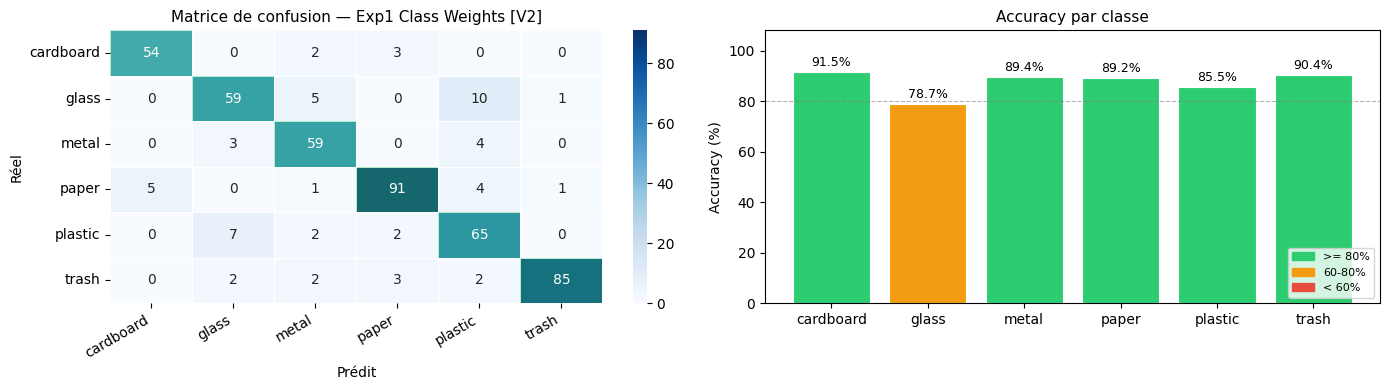

Modèle V2 Exp 1 sauvegardé → ../model/v2_exp1_class_weights.keras


In [7]:
# ── Évaluation & sauvegarde ───────────────────────────────────────────
acc_v2_exp1, loss_v2_exp1, pred_v2_exp1, true_v2_exp1 = evaluate_model(
    model_v2_exp1, test_dataset, class_names, 'Exp1 Class Weights'
)
model_v2_exp1.save('../model/v2_exp1_class_weights.keras')
print('Modèle V2 Exp 1 sauvegardé → ../model/v2_exp1_class_weights.keras')

---
# Expérience 2 — Fine-tuning MobileNetV2 [V2]

On part du **modèle baseline original** (`waste_classifier.keras`) et on applique
le fine-tuning sur le dataset enrichi.

In [8]:
# ── Charger le baseline original comme point de départ ───────────────
model_v2_exp2 = load_model('../model/waste_classifier.keras')

# ── Identifier et dégeler les 30 dernières couches MobileNetV2 ────────
mobilenet_layer = None
for layer in model_v2_exp2.layers:
    if 'mobilenetv2' in layer.name.lower():
        mobilenet_layer = layer
        break

if mobilenet_layer is None:
    raise ValueError('Couche MobileNetV2 introuvable dans le modèle chargé.')

mobilenet_layer.trainable = True
for layer in mobilenet_layer.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in mobilenet_layer.layers if l.trainable)
print(f'Couche MobileNetV2 : {mobilenet_layer.name}')
print(f'Couches dégelées   : {trainable_count} / {len(mobilenet_layer.layers)}')

Couche MobileNetV2 : mobilenetv2_1.00_224
Couches dégelées   : 30 / 154


In [9]:
# ── Recompiler avec lr faible (OBLIGATOIRE après changement trainable) ─
model_v2_exp2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print('Modèle V2 Exp 2 recompilé avec lr=1e-5')

Modèle V2 Exp 2 recompilé avec lr=1e-5


In [10]:
# ── Fine-tuning sur dataset enrichi ───────────────────────────────────
history_v2_exp2 = model_v2_exp2.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 60s 785ms/step - accuracy: 0.7397 - loss: 0.7841 - val_accuracy: 0.8678 - val_loss: 0.3693
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 48s 749ms/step - accuracy: 0.8145 - loss: 0.5149 - val_accuracy: 0.8870 - val_loss: 0.3287
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 48s 746ms/step - accuracy: 0.8364 - loss: 0.4465 - val_accuracy: 0.8870 - val_loss: 0.3090
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 47s 740ms/step - accuracy: 0.8521 - loss: 0.4226 - val_accuracy: 0.8918 - val_loss: 0.3046
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 47s 736ms/step - accuracy: 0.8691 - loss: 0.3662 - val_accuracy: 0.8918 - val_loss: 0.2919
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 48s 740ms/step - accuracy: 0.8691 - loss: 0.3572 - val_accuracy: 0.9014 - val_loss: 0.2793
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 48s 744ms/step - accuracy: 0.8682 - loss: 0.3514 - val_accuracy: 0.9062 - val_loss: 0.2709
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 48s 743ms/step - accuracy: 0.8965 - loss: 0.3025 - val_accu

  RÉSULTATS — Exp2 Fine-tuning [V2 — Dataset Augmenté]
  Test Accuracy : 87.08%
  Test Loss     : 0.3770

              precision    recall  f1-score   support

   cardboard      0.859     0.932     0.894        59
       glass      0.774     0.867     0.818        75
       metal      0.811     0.909     0.857        66
       paper      0.917     0.863     0.889       102
     plastic      0.908     0.776     0.837        76
       trash      0.944     0.894     0.918        94

    accuracy                          0.871       472
   macro avg      0.869     0.873     0.869       472
weighted avg      0.876     0.871     0.871       472



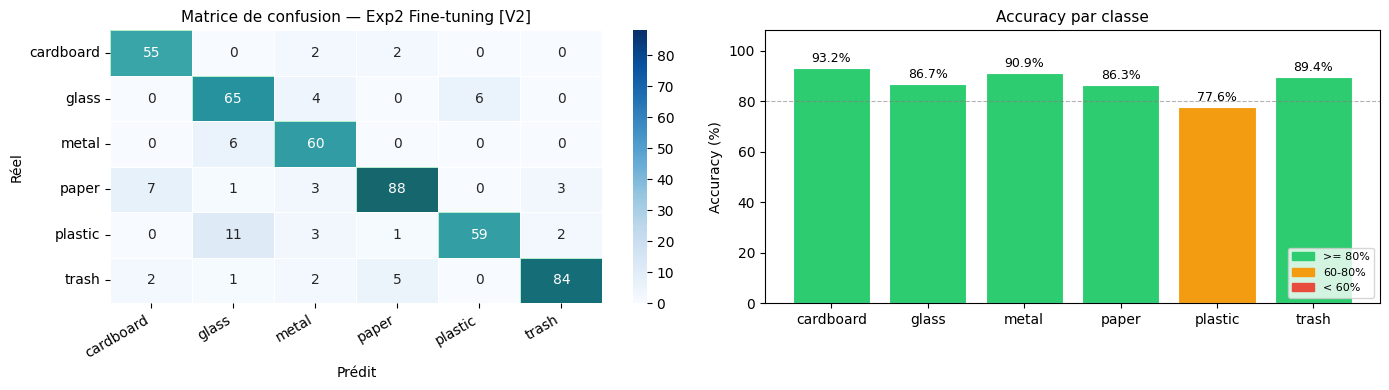

Modèle V2 Exp 2 sauvegardé → ../model/v2_exp2_fine_tuned.keras


In [11]:
# ── Évaluation & sauvegarde ───────────────────────────────────────────
acc_v2_exp2, loss_v2_exp2, pred_v2_exp2, true_v2_exp2 = evaluate_model(
    model_v2_exp2, test_dataset, class_names, 'Exp2 Fine-tuning'
)
model_v2_exp2.save('../model/v2_exp2_fine_tuned.keras')
print('Modèle V2 Exp 2 sauvegardé → ../model/v2_exp2_fine_tuned.keras')

---
# Expérience 3 — Class Weights + Fine-tuning [V2]

On part du modèle V2 Exp 1 (class weights sur dataset enrichi)
et on applique le fine-tuning par-dessus.

In [12]:
# ── Partir du modèle V2 Exp 1 ────────────────────────────────────────
model_v2_exp3 = load_model('../model/v2_exp1_class_weights.keras')

# ── Dégeler les 30 dernières couches de MobileNetV2 ───────────────────
for layer in model_v2_exp3.layers:
    if 'mobilenetv2' in layer.name.lower():
        layer.trainable = True
        for sub in layer.layers[:-30]:
            sub.trainable = False
        trainable = sum(1 for l in layer.layers if l.trainable)
        print(f'MobileNetV2 : {trainable} couches dégelées sur {len(layer.layers)}')
        break

# ── Recompiler ────────────────────────────────────────────────────────
model_v2_exp3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print('Modèle V2 Exp 3 prêt.')

MobileNetV2 : 30 couches dégelées sur 154
Modèle V2 Exp 3 prêt.


In [13]:
# ── Fine-tuning avec class weights sur dataset enrichi ────────────────
history_v2_exp3 = model_v2_exp3.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    class_weight=class_weight_dict
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 63s 792ms/step - accuracy: 0.8159 - loss: 0.5015 - val_accuracy: 0.9183 - val_loss: 0.2750
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 46s 722ms/step - accuracy: 0.8589 - loss: 0.3881 - val_accuracy: 0.9207 - val_loss: 0.2755
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 48s 742ms/step - accuracy: 0.8745 - loss: 0.3507 - val_accuracy: 0.9159 - val_loss: 0.2750
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 51s 795ms/step - accuracy: 0.8857 - loss: 0.3213 - val_accuracy: 0.9255 - val_loss: 0.2723
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 48s 750ms/step - accuracy: 0.8843 - loss: 0.3089 - val_accuracy: 0.9183 - val_loss: 0.2707
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 47s 736ms/step - accuracy: 0.8828 - loss: 0.3201 - val_accuracy: 0.9183 - val_loss: 0.2664
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 48s 746ms/step - accuracy: 0.9048 - loss: 0.2687 - val_accuracy: 0.9207 - val_loss: 0.2636
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 47s 735ms/step - accuracy: 0.9077 - loss: 0.2620 - val_accu

  RÉSULTATS — Exp3 CW + Fine-tuning [V2 — Dataset Augmenté]
  Test Accuracy : 88.14%
  Test Loss     : 0.3523

              precision    recall  f1-score   support

   cardboard      0.898     0.898     0.898        59
       glass      0.797     0.840     0.818        75
       metal      0.818     0.955     0.881        66
       paper      0.910     0.892     0.901       102
     plastic      0.857     0.789     0.822        76
       trash      0.989     0.915     0.950        94

    accuracy                          0.881       472
   macro avg      0.878     0.882     0.878       472
weighted avg      0.885     0.881     0.882       472



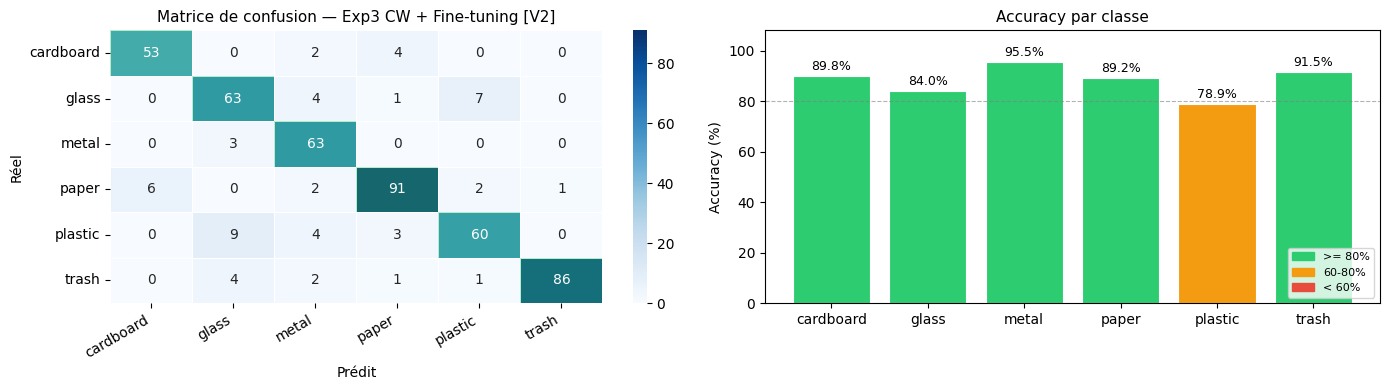

Modèle V2 Exp 3 sauvegardé → ../model/v2_exp3_combined.keras


In [14]:
# ── Évaluation & sauvegarde ───────────────────────────────────────────
acc_v2_exp3, loss_v2_exp3, pred_v2_exp3, true_v2_exp3 = evaluate_model(
    model_v2_exp3, test_dataset, class_names, 'Exp3 CW + Fine-tuning'
)
model_v2_exp3.save('../model/v2_exp3_combined.keras')
print('Modèle V2 Exp 3 sauvegardé → ../model/v2_exp3_combined.keras')

---
# Comparaison finale — V2 vs Originaux

On compare les résultats V2 (dataset enrichi) avec les résultats originaux
pour mesurer l'impact de l'augmentation offline.

In [15]:
# ── Résultats originaux (depuis experiments_improvements.ipynb) ───────
results_original = {
    'Baseline'              : 0.8450,
    'Exp 1 — Class weights' : 0.8596,
    'Exp 2 — Fine-tuning'   : 0.8741,
    'Exp 3 — CW + FT'       : 0.8717,
}

# ── Résultats V2 (ce notebook) ────────────────────────────────────────
results_v2 = {
    'Baseline'              : 0.8450,   # inchangé
    'V2 Exp 1 — CW'         : acc_v2_exp1,
    'V2 Exp 2 — Fine-tuning': acc_v2_exp2,
    'V2 Exp 3 — CW + FT'    : acc_v2_exp3,
}

print('=' * 65)
print('  COMPARAISON : ORIGINAL vs V2 (Dataset Augmenté)')
print('=' * 65)
print(f'  {"Expérience":28s}  {"Original":>10s}  {"V2":>10s}  {"Delta":>8s}')
print('─' * 65)

pairs = [
    ('Baseline',        'Baseline',              'Baseline'),
    ('Exp 1 — CW',      'Exp 1 — Class weights', 'V2 Exp 1 — CW'),
    ('Exp 2 — FT',      'Exp 2 — Fine-tuning',   'V2 Exp 2 — Fine-tuning'),
    ('Exp 3 — CW + FT', 'Exp 3 — CW + FT',       'V2 Exp 3 — CW + FT'),
]

for label, orig_key, v2_key in pairs:
    orig = results_original[orig_key]
    v2   = results_v2[v2_key]
    delta = v2 - orig
    sign  = '+' if delta >= 0 else ''
    arrow = '↑' if delta > 0.005 else ('↓' if delta < -0.005 else '≈')
    print(f'  {label:28s}  {orig*100:>9.2f}%  {v2*100:>9.2f}%  {sign}{delta*100:>6.2f}% {arrow}')

print('=' * 65)

best_v2 = max(results_v2, key=results_v2.get)
print(f'\n  Meilleur modèle V2 : {best_v2} ({results_v2[best_v2]*100:.2f}%)')

  COMPARAISON : ORIGINAL vs V2 (Dataset Augmenté)
  Expérience                      Original          V2     Delta
─────────────────────────────────────────────────────────────────
  Baseline                          84.50%      84.50%  +  0.00% ≈
  Exp 1 — CW                        85.96%      87.50%  +  1.54% ↑
  Exp 2 — FT                        87.41%      87.08%   -0.33% ≈
  Exp 3 — CW + FT                   87.17%      88.14%  +  0.97% ↑

  Meilleur modèle V2 : V2 Exp 3 — CW + FT (88.14%)


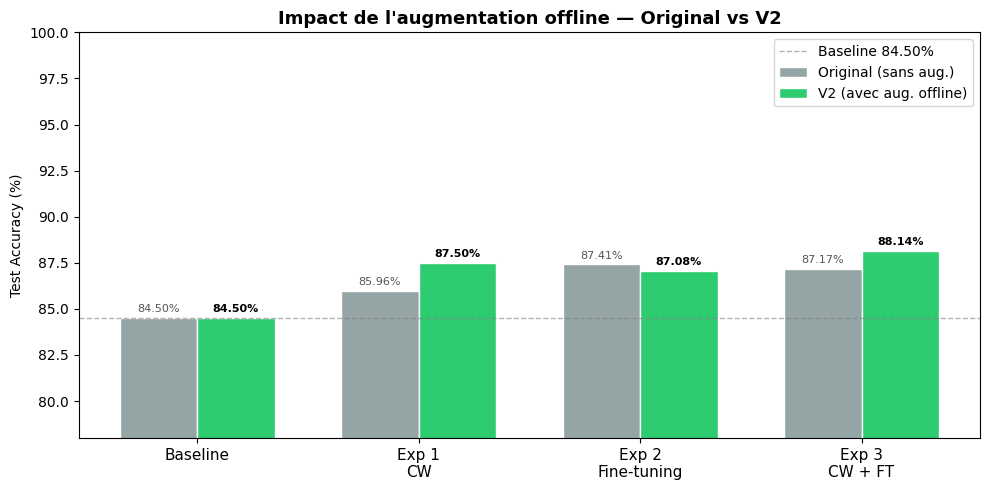

Graphique sauvegardé → ../model/v2_experiments_comparison.png


In [16]:
# ── Graphique comparatif Original vs V2 ──────────────────────────────
labels   = ['Baseline', 'Exp 1\nCW', 'Exp 2\nFine-tuning', 'Exp 3\nCW + FT']
orig_vals = [0.8450, results_original['Exp 1 — Class weights'],
             results_original['Exp 2 — Fine-tuning'], results_original['Exp 3 — CW + FT']]
v2_vals   = [0.8450, acc_v2_exp1, acc_v2_exp2, acc_v2_exp3]

x     = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, [v*100 for v in orig_vals], width,
               label='Original (sans aug.)', color='#95a5a6', edgecolor='white')
bars2 = ax.bar(x + width/2, [v*100 for v in v2_vals], width,
               label='V2 (avec aug. offline)', color='#2ecc71', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=8, color='#555')
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.axhline(84.50, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='Baseline 84.50%')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(78, 100)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Impact de l\'augmentation offline — Original vs V2', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../model/v2_experiments_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé → ../model/v2_experiments_comparison.png')

In [17]:
# ── Sauvegarder le meilleur modèle V2 ────────────────────────────────
best_map_v2 = {
    'Baseline'               : '../model/waste_classifier.keras',
    'V2 Exp 1 — CW'          : '../model/v2_exp1_class_weights.keras',
    'V2 Exp 2 — Fine-tuning' : '../model/v2_exp2_fine_tuned.keras',
    'V2 Exp 3 — CW + FT'     : '../model/v2_exp3_combined.keras',
}

# Forcer Exp 3 V2 comme modèle final (meilleur équilibre inter-classes)
chosen_name = 'V2 Exp 3 — CW + FT'
chosen_src  = best_map_v2[chosen_name]
shutil.copy(chosen_src, '../model/v2_best_model.keras')

print(f'Modèle choisi   : {chosen_name}')
print(f'Accuracy        : {results_v2[chosen_name]*100:.2f}%')
print(f'Sauvegardé sous : ../model/v2_best_model.keras')

Modèle choisi   : V2 Exp 3 — CW + FT
Accuracy        : 88.14%
Sauvegardé sous : ../model/v2_best_model.keras


---
## Conclusion

| Fichier généré | Description |
|---|---|
| `v2_exp1_class_weights.keras` | Exp 1 sur dataset enrichi |
| `v2_exp2_fine_tuned.keras` | Exp 2 sur dataset enrichi |
| `v2_exp3_combined.keras` | Exp 3 sur dataset enrichi |
| `v2_best_model.keras` | Modèle final retenu (Exp 3 V2) |
| `v2_experiments_comparison.png` | Graphique Original vs V2 |

> Les fichiers originaux (`exp1_class_weights.keras`, `exp2_fine_tuned.keras`,
> `exp3_combined.keras`, `best_model.keras`, `experiments_comparison.png`)
> sont **inchangés** et toujours disponibles pour comparaison.